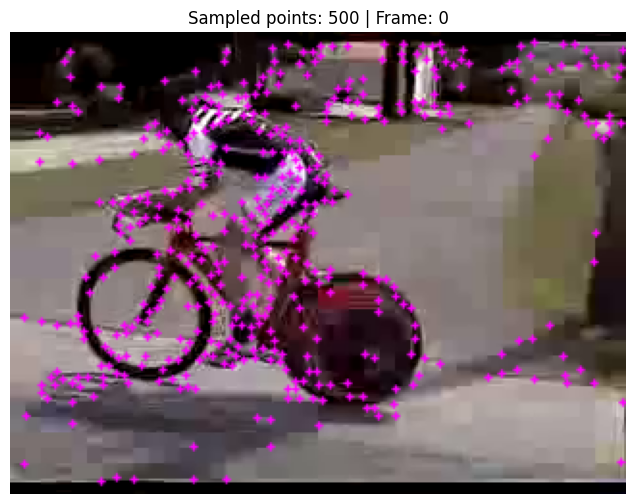

Saved overlay image to: /scratch/pbk5339/rl_project/goodfeature_points_overlay.png
Number of sampled points: 500


In [8]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Update this path if you want a different video
VIDEO_PATH = "UCF_Rep/val/v_Biking_g21_c01.mp4"
OUTPUT_PATH = "goodfeature_points_overlay.png"
FRAME_INDEX = 0

video_path = Path(VIDEO_PATH)
if not video_path.exists():
    raise FileNotFoundError(f"Video not found: {video_path.resolve()}")

cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise ValueError(f"Could not open video: {video_path}")

try:
    cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INDEX)
    ret, frame = cap.read()
    if not ret:
        raise ValueError(f"Could not read frame index {FRAME_INDEX} from {video_path}")
finally:
    cap.release()

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Same sampling config as in func_utils.py
points = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=500,
    qualityLevel=0.005,
    minDistance=4,
    blockSize=3,
)

overlay = frame.copy()
point_count = 0
if points is not None and len(points) > 0:
    pts = points.reshape(-1, 2)
    point_count = pts.shape[0]

    # New style: tiny magenta cross markers with anti-aliasing
    for x, y in pts:
        cv2.drawMarker(
            overlay,
            (int(round(x)), int(round(y))),
            color=(255, 0, 255),
            markerType=cv2.MARKER_CROSS,
            markerSize=5,
            thickness=1,
            line_type=cv2.LINE_AA,
        )

cv2.imwrite(OUTPUT_PATH, overlay)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"Sampled points: {point_count} | Frame: {FRAME_INDEX}")
plt.axis("off")
plt.show()

print(f"Saved overlay image to: {Path(OUTPUT_PATH).resolve()}")
print(f"Number of sampled points: {point_count}")

In [ ]:
from collections import deque
from pathlib import Path

import cv2
import numpy as np
from IPython.display import Video, display

# Uses VIDEO_PATH / FRAME_INDEX / points from Cell 1 when available
video_path = Path(VIDEO_PATH if 'VIDEO_PATH' in globals() else "UCF_Rep/val/v_Biking_g21_c01.mp4")
frame_index = FRAME_INDEX if 'FRAME_INDEX' in globals() else 0
tracking_output_path = Path("optical_flow_tracking_overlay_2.mp4")

if not video_path.exists():
    raise FileNotFoundError(f"Video not found: {video_path.resolve()}")

cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise ValueError(f"Could not open video: {video_path}")

try:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ret, first_frame = cap.read()
    if not ret:
        raise ValueError(f"Could not read frame index {frame_index} from {video_path}")

    first_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)

    # Prefer sampled points from Cell 1; fallback to same config as func_utils.py
    if 'points' in globals() and points is not None and len(points) > 0:
        init_points = points.astype(np.float32)
    else:
        init_points = cv2.goodFeaturesToTrack(
            first_gray,
            maxCorners=500,
            qualityLevel=0.005,
            minDistance=4,
            blockSize=3,
        )

    if init_points is None or len(init_points) == 0:
        raise ValueError("No points available for tracking.")

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 30.0

    writer = cv2.VideoWriter(
        str(tracking_output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height),
    )

    lk_params = dict(
        winSize=(21, 21),
        maxLevel=3,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01),
    )

    # Track only active points, but keep stable identity for trails
    active_ids = np.arange(init_points.shape[0], dtype=np.int32)
    prev_pts = init_points.reshape(-1, 1, 2)
    trails = [deque(maxlen=12) for _ in range(init_points.shape[0])]

    for pid, pt in zip(active_ids, prev_pts.reshape(-1, 2)):
        trails[int(pid)].append((float(pt[0]), float(pt[1])))

    # Draw first frame
    frame_vis = first_frame.copy()
    for pid in active_ids:
        trail = trails[int(pid)]
        if not trail:
            continue
        x, y = trail[-1]
        cv2.circle(frame_vis, (int(round(x)), int(round(y))), 2, (255, 220, 0), -1, lineType=cv2.LINE_AA)
    writer.write(frame_vis)

    prev_gray = first_gray
    tracked_frames = 1

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if prev_pts is None or len(prev_pts) == 0:
            writer.write(frame)
            prev_gray = gray
            tracked_frames += 1
            continue

        next_pts, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray, gray, prev_pts, None, **lk_params)

        if next_pts is None or status is None:
            writer.write(frame)
            prev_gray = gray
            prev_pts = np.empty((0, 1, 2), dtype=np.float32)
            active_ids = np.empty((0,), dtype=np.int32)
            tracked_frames += 1
            continue

        valid = status.reshape(-1) == 1
        good_new = next_pts.reshape(-1, 2)[valid]
        good_ids = active_ids[valid]

        frame_vis = frame.copy()

        # Draw current points only
        for pid, (x, y) in zip(good_ids, good_new):
            cv2.circle(frame_vis, (int(round(x)), int(round(y))), 2, (0, 255, 255), -1, lineType=cv2.LINE_AA)

        writer.write(frame_vis)

        prev_gray = gray
        prev_pts = good_new.reshape(-1, 1, 2).astype(np.float32)
        active_ids = good_ids
        tracked_frames += 1

finally:
    cap.release()
    if 'writer' in locals():
        writer.release()

print(f"Saved tracking video to: {tracking_output_path.resolve()}")
print(f"Frames processed: {tracked_frames}")
print(f"Active points remaining at end: {len(active_ids) if 'active_ids' in locals() else 0}")

display(Video(str(tracking_output_path), embed=True, html_attributes="controls loop"))

Saved tracking video to: /scratch/pbk5339/rl_project/optical_flow_tracking_overlay_2.mp4
Frames processed: 230
Active points remaining at end: 233


In [3]:
import os

os.environ["TORCH_HOME"] = "/scratch/pbk5339/caches/torch"
os.environ["XDG_CACHE_HOME"] = "/scratch/pbk5339/caches/xdg"
os.environ["HF_HOME"] = "/scratch/pbk5339/caches/hf"

Using cache found in /scratch/pbk5339/caches/torch/hub/facebookresearch_dinov2_main
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06643185..1.0780162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06643185..1.0780162].


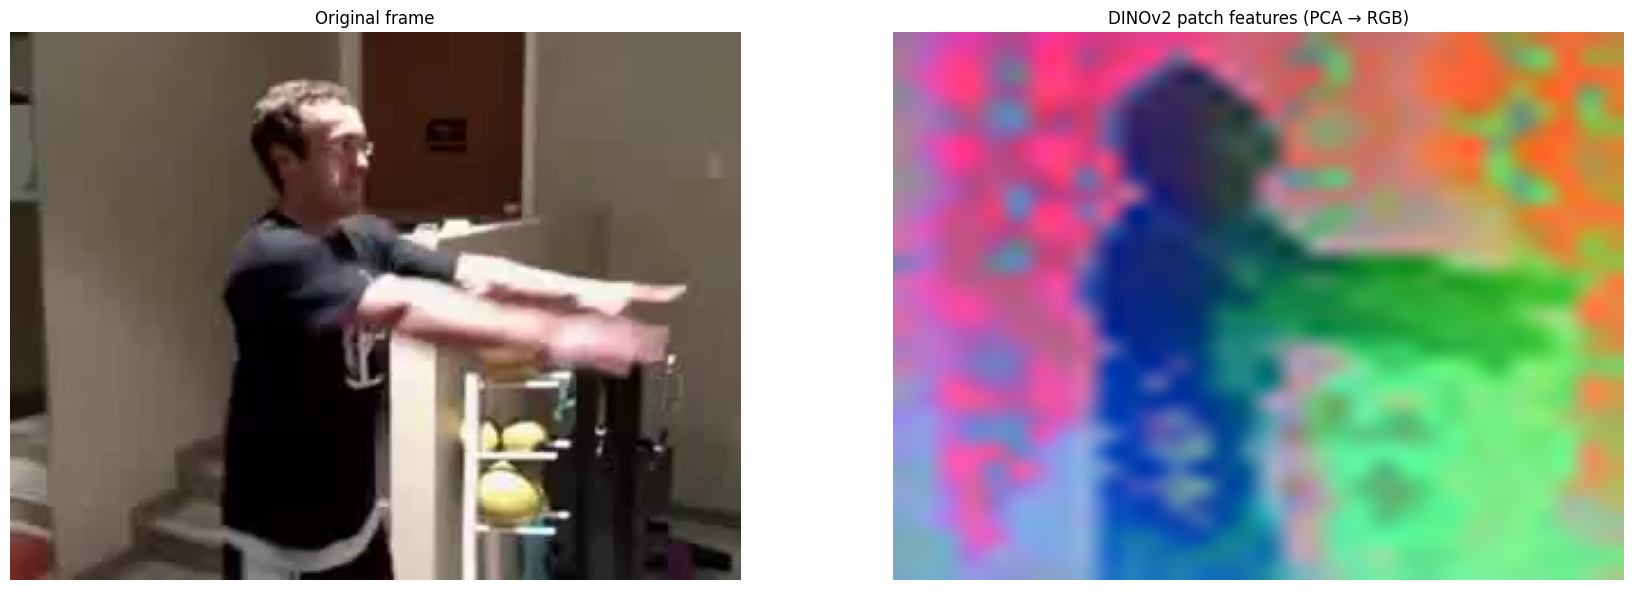

Patch grid: 32 x 32, feature dim: 384


In [7]:
from pathlib import Path

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from sklearn.decomposition import PCA

# DINOv2 feature visualization for a single frame/image
VIDEO_PATH = VIDEO_PATH if 'VIDEO_PATH' in globals() else "UCF_Rep/val/v_BodyWeightSquats_g24_c01.mp4"
FRAME_INDEX = FRAME_INDEX if 'FRAME_INDEX' in globals() else 0

video_path = Path(VIDEO_PATH)
if not video_path.exists():
    raise FileNotFoundError(f"Video not found: {video_path.resolve()}")

cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise ValueError(f"Could not open video: {video_path}")

try:
    cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INDEX)
    ret, frame = cap.read()
    if not ret:
        raise ValueError(f"Could not read frame {FRAME_INDEX} from {video_path}")
finally:
    cap.release()

# Use a smaller display size so the code runs quickly and looks clean
img_bgr = frame
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_pil = Image.fromarray(img_rgb)

# Match DINOv2 preprocessing style
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = transform(img_pil).unsqueeze(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the same DINOv2 backbone used in your pipeline
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)
model.eval()

with torch.no_grad():
    feats = model.get_intermediate_layers(input_tensor.to(device), n=1)[0]

# Remove CLS token if present, then reshape patch tokens into a grid
if feats.shape[1] == 1024:
    patch_tokens = feats.reshape(1, 32, 32, -1)[0].cpu().numpy()
else:
    patch_tokens = feats[:, 1:, :].reshape(1, 32, 32, -1)[0].cpu().numpy()

H, W, C = patch_tokens.shape
flat = patch_tokens.reshape(-1, C)

# Best general-purpose visualization: PCA to 3 channels
pca_rgb = PCA(n_components=3, random_state=0)
proj3 = pca_rgb.fit_transform(flat)
proj3 = proj3.reshape(H, W, 3)
proj3 = (proj3 - proj3.min()) / (proj3.max() - proj3.min() + 1e-8)
proj3_up = cv2.resize(proj3, (img_rgb.shape[1], img_rgb.shape[0]), interpolation=cv2.INTER_CUBIC)

# # One-channel semantic energy map: first PCA component
# pca_1 = PCA(n_components=1, random_state=0)
# proj1 = pca_1.fit_transform(flat).reshape(H, W)
# proj1 = (proj1 - proj1.min()) / (proj1.max() - proj1.min() + 1e-8)
# proj1_up = cv2.resize(proj1, (img_rgb.shape[1], img_rgb.shape[0]), interpolation=cv2.INTER_CUBIC)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Original frame')
axes[0].axis('off')

axes[1].imshow(proj3_up)
axes[1].set_title('DINOv2 patch features (PCA → RGB)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Patch grid: {H} x {W}, feature dim: {C}')